In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
MODEL_NAME = "convnext_base"

INPUT_DIRS = [
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-positive-part-1",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs-part3",
    "/kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-pngs",
]

TRAIN_CSV = ("/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/"
             "rsna-intracranial-hemorrhage-detection/stage_2_train.csv")

MIN_FILE_SIZE_KB = 40
MIN_FILE_SIZE_BYTES = MIN_FILE_SIZE_KB * 1024

LABEL_COLS = ["any", "epidural", "intraparenchymal",
              "intraventricular", "subarachnoid", "subdural"]

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

EARLY_STOPPING_PATIENCE = 5
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
TEST_IDS_PATH = "/kaggle/working/test_ids.csv"

NUM_WORKERS = 4


def load_labels(csv_path):
    y = pd.read_csv(csv_path)
    id_split = y.ID.str.rsplit("_", n=1, expand=True)
    y = pd.concat([id_split, y.Label], axis=1)
    y.columns = ["id", "sub_type", "label"]
    y = y.drop_duplicates(subset=["id", "sub_type"])
    df = y.pivot(index="id", columns="sub_type", values="label")
    return df


class ICHDataset(Dataset):
    def __init__(self, df, id_to_path, transform=None):
        self.df = df
        self.id_to_path = id_to_path
        self.transform = transform
        self.ids = df.index.values
        self.labels = df[LABEL_COLS].values.astype(np.float32)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        path = self.id_to_path[img_id]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


class BalancedRandomSampler(Sampler):
    def __init__(self, labels_any):
        self.pos_idx = np.where(labels_any == 1)[0]
        self.neg_idx = np.where(labels_any == 0)[0]

    def __iter__(self):
        n = min(len(self.neg_idx), max(len(self.pos_idx), 1))
        neg_sample = np.random.choice(self.neg_idx, n, replace=False)
        pos_sample = (np.random.choice(self.pos_idx, n, replace=False)
                      if len(self.pos_idx) > 0 else np.array([], dtype=int))
        ids = np.concatenate([pos_sample, neg_sample])
        np.random.shuffle(ids)
        return iter(ids.tolist())

    def __len__(self):
        return min(len(self.neg_idx), max(len(self.pos_idx), 1)) * 2


def build_convnext_base(num_classes=len(LABEL_COLS)):
    model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # unfreeze only the last stage (features[-1]), same "last-block-only" pattern as ViT/ResNet
    for param in model.features[-1].parameters():
        param.requires_grad = True
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model.to(DEVICE)


MODEL_BUILDERS = {"convnext_base": build_convnext_base}

OPTIMIZER_CONFIG = {
    "convnext_base": {"type": "adamw", "lr": 1e-4, "weight_decay": 1e-4},
}

SCHEDULER_CONFIG = {
    "convnext_base": {"warmup_epochs": 1},
}


def build_optimizer(model, model_name):
    cfg = OPTIMIZER_CONFIG[model_name]
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if cfg["type"] == "sgd":
        return torch.optim.SGD(trainable_params, lr=cfg["lr"], momentum=cfg["momentum"])
    elif cfg["type"] == "adamw":
        return torch.optim.AdamW(trainable_params, lr=cfg["lr"],
                                  weight_decay=cfg.get("weight_decay", 0.0))
    else:
        raise ValueError(f"Unknown optimizer type: {cfg['type']}")


def build_scheduler(optimizer, model_name, num_epochs):
    warmup_epochs = SCHEDULER_CONFIG[model_name]["warmup_epochs"]
    warmup_epochs = min(warmup_epochs, max(num_epochs - 1, 0))

    if warmup_epochs > 0:
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(num_epochs - warmup_epochs, 1)
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    return scheduler


def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch, num_epochs):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"train epoch {epoch+1}/{num_epochs}", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()

        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, epoch, num_epochs):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc=f"val epoch {epoch+1}/{num_epochs}", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        all_preds.append(torch.sigmoid(outputs.float()).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    aucs = {}
    for i, name in enumerate(LABEL_COLS):
        if len(np.unique(all_labels[:, i])) > 1:
            aucs[name] = roc_auc_score(all_labels[:, i], all_preds[:, i])
        else:
            aucs[name] = float("nan")

    return total_loss / len(loader.dataset), aucs


def run_training(model_name, train_ds, val_ds, y_train):
    print(f"\n{'='*60}")
    print(f"FULL TRAINING RUN: {model_name}")
    print(f"{'='*60}")

    model = MODEL_BUILDERS[model_name]()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = build_optimizer(model, model_name)
    scheduler = build_scheduler(optimizer, model_name, NUM_EPOCHS)
    scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_AMP)

    sampler = BalancedRandomSampler(y_train["any"].values)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS, pin_memory=True,
                               persistent_workers=True, prefetch_factor=4)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True,
                             persistent_workers=True, prefetch_factor=4)

    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.pt")

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        current_lr = optimizer.param_groups[0]["lr"]

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                      scaler, epoch, NUM_EPOCHS)
        val_loss, val_aucs = evaluate(model, val_loader, criterion, epoch, NUM_EPOCHS)

        auc_str = ", ".join(f"{k}={v:.3f}" for k, v in val_aucs.items())
        print(f"[{model_name}] Epoch {epoch+1}/{NUM_EPOCHS} | lr={current_lr:.2e} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {auc_str}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                "model_name": model_name,
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_aucs": val_aucs,
            }, checkpoint_path)
            print(f"[{model_name}]   -> val loss improved, checkpoint saved to {checkpoint_path}")
        else:
            epochs_no_improve += 1
            print(f"[{model_name}]   -> no improvement ({epochs_no_improve}/{EARLY_STOPPING_PATIENCE})")

        scheduler.step()

        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"[{model_name}] Early stopping triggered at epoch {epoch+1}.")
            break

    print(f"[{model_name}] Training complete. Best val_loss={best_val_loss:.4f}, "
          f"checkpoint at {checkpoint_path}")


def scan_input_dirs(input_dirs, min_size_bytes):
    id_to_path = {}
    skipped_small = 0
    for d in input_dirs:
        if not os.path.isdir(d):
            print(f"WARNING: directory not found, skipping: {d}")
            continue
        print(f"listing {d} ...", flush=True)
        filenames = [f for f in os.listdir(d) if f.endswith(".png")]
        print(f"  -> {len(filenames)} png files, scanning sizes...", flush=True)
        for f in tqdm(filenames, desc=f"scanning {os.path.basename(d)}"):
            full_path = os.path.join(d, f)
            if os.path.getsize(full_path) <= min_size_bytes:
                skipped_small += 1
                continue
            img_id = f[:-4]
            id_to_path[img_id] = full_path
    print(f"Scanned {len(input_dirs)} directories: {len(id_to_path)} usable PNGs "
          f"found, {skipped_small} filtered out as low-information (<= "
          f"{min_size_bytes} bytes / {MIN_FILE_SIZE_KB}KB).")
    return id_to_path


def make_splits(df):
    train_df, temp_df = train_test_split(
        df, test_size=VAL_SPLIT + TEST_SPLIT, stratify=df["any"], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
        stratify=temp_df["any"], random_state=42
    )
    return train_df, val_df, test_df


def main():
    print(f"*** FULL TRAINING RUN: {MODEL_NAME} ***")
    print(f"Using device: {DEVICE} | AMP enabled: {USE_AMP}")

    id_to_path = scan_input_dirs(INPUT_DIRS, MIN_FILE_SIZE_BYTES)

    if len(id_to_path) == 0:
        print("\nNo usable PNGs found across INPUT_DIRS. Check the paths are "
              "correct and the datasets are actually attached as Input.")
        return

    df = load_labels(TRAIN_CSV)
    df = df[df.index.isin(id_to_path.keys())]
    print(f"Matched {len(df)} of those to labels. "
          f"Positive rate: {df['any'].mean():.4f}")

    train_df, val_df, test_df = make_splits(df)
    print(f"Full run sizes — train: {len(train_df)}, val: {len(val_df)}, "
          f"test: {len(test_df)}")

    os.makedirs(os.path.dirname(TEST_IDS_PATH), exist_ok=True)
    test_df.index.to_series(name="id").to_csv(TEST_IDS_PATH, index=False)
    print(f"Saved test set ids to {TEST_IDS_PATH}")

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])

    global train_df_g, val_df_g, test_df_g, id_to_path_g
    train_df_g, val_df_g, test_df_g, id_to_path_g = train_df, val_df, test_df, id_to_path

    train_ds = ICHDataset(train_df, id_to_path, transform=train_transform)
    val_ds = ICHDataset(val_df, id_to_path, transform=eval_transform)

    global val_ds_g
    val_ds_g = val_ds

    run_training(MODEL_NAME, train_ds, val_ds, train_df)


main()

*** FULL TRAINING RUN: convnext_base ***
Using device: cuda | AMP enabled: True
listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part1 ...
  -> 64000 png files, scanning sizes...


scanning rsna-ich-preprocessed-negative-part1:   0%|          | 0/64000 [00:00<?, ?it/s]

listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part2 ...
  -> 64000 png files, scanning sizes...


scanning rsna-ich-preprocessed-negative-part2:   0%|          | 0/64000 [00:00<?, ?it/s]

listing /kaggle/input/datasets/anushakirand/rsna-ich-preprocessed-negative-part3 ...
  -> 64067 png files, scanning sizes...


...

val epoch 14/15:   0%|          | 0/1262 [00:00<?, ?it/s]

[convnext_base] Epoch 14/15 | lr=4.95e-06 | train_loss=0.1745 | val_loss=0.1769 | any=0.956, epidural=0.922, intraparenchymal=0.953, intraventricular=0.976, subarachnoid=0.906, subdural=0.939
[convnext_base]   -> no improvement (1/5)


train epoch 15/15:   0%|          | 0/4697 [00:00<?, ?it/s]

val epoch 15/15:   0%|          | 0/1262 [00:00<?, ?it/s]

[convnext_base] Epoch 15/15 | lr=1.25e-06 | train_loss=0.1727 | val_loss=0.1762 | any=0.956, epidural=0.922, intraparenchymal=0.953, intraventricular=0.976, subarachnoid=0.906, subdural=0.940
[convnext_base]   -> no improvement (2/5)
[convnext_base] Training complete. Best val_loss=0.1759, checkpoint at /kaggle/working/checkpoints/convnext_base_best.pt


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, f1_score,
)

MODEL_NAME = "convnext_base"
CHECKPOINT_PATH = f"/kaggle/working/checkpoints/{MODEL_NAME}_best.pt"


def build_convnext_base(num_classes=len(LABEL_COLS)):
    model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[-1].parameters():
        param.requires_grad = True
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model.to(DEVICE)


MODEL_BUILDERS = {"convnext_base": build_convnext_base}

# Reuse from Cell 1 if present, else rebuild
if "val_df_g" in globals() and "test_df_g" in globals() and "id_to_path_g" in globals():
    print("Reusing splits from training cell.")
    val_df, test_df, id_to_path = val_df_g, test_df_g, id_to_path_g
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])
    val_ds = ICHDataset(val_df, id_to_path, transform=eval_transform)
    test_ds = ICHDataset(test_df, id_to_path, transform=eval_transform)
else:
    print("Splits not found in memory — rebuilding (same random_state=42).")
    id_to_path = scan_input_dirs(INPUT_DIRS, MIN_FILE_SIZE_BYTES)
    df = load_labels(TRAIN_CSV)
    df = df[df.index.isin(id_to_path.keys())]
    _, val_df, test_df = make_splits(df)
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])
    val_ds = ICHDataset(val_df, id_to_path, transform=eval_transform)
    test_ds = ICHDataset(test_df, id_to_path, transform=eval_transform)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

model = MODEL_BUILDERS[MODEL_NAME]()
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded checkpoint: epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.4f}")


@torch.no_grad()
def run_inference(loader):
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
        probs = torch.sigmoid(outputs.float()).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


print("Running inference on val split (threshold selection only)...")
val_probs, val_labels = run_inference(val_loader)
print("Running inference on test split (reported numbers)...")
test_probs, test_labels = run_inference(test_loader)
print(f"Done: {len(val_probs)} val images, {len(test_probs)} test images.")


def best_f1_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.nanargmax(f1s[:-1])
    return thresholds[best_idx] if len(thresholds) > 0 else 0.5


rows = []
confusion_matrices = {}

for i, name in enumerate(LABEL_COLS):
    y_true_val = val_labels[:, i]
    y_true_test = test_labels[:, i]
    y_prob_test = test_probs[:, i]

    if len(np.unique(y_true_val)) < 2 or len(np.unique(y_true_test)) < 2:
        continue

    thresh = best_f1_threshold(y_true_val, val_probs[:, i])
    y_pred_test = (y_prob_test >= thresh).astype(int)

    roc_auc = roc_auc_score(y_true_test, y_prob_test)
    pr_auc = average_precision_score(y_true_test, y_prob_test)

    tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true_test, y_pred_test, zero_division=0)

    confusion_matrices[name] = np.array([[tn, fp], [fn, tp]])

    rows.append({
        "class": name, "roc_auc": roc_auc, "pr_auc": pr_auc,
        "threshold_from_val": thresh, "precision": precision,
        "recall_sensitivity": recall, "specificity": specificity, "f1": f1,
        "n_positive": int(y_true_test.sum()), "n_total": len(y_true_test),
    })

results_df = pd.DataFrame(rows).set_index("class")
macro_auc = roc_auc_score(test_labels, test_probs, average="macro")
micro_auc = roc_auc_score(test_labels, test_probs, average="micro")

print("\n" + "=" * 90)
print(f"PER-CLASS METRICS (test split) — {MODEL_NAME}, checkpoint epoch {checkpoint['epoch']}")
print("=" * 90)
print(results_df.round(4).to_string())
print(f"\nMacro-average ROC-AUC: {macro_auc:.4f}")
print(f"Micro-average ROC-AUC: {micro_auc:.4f}")

print("\n" + "=" * 90)
print("CONFUSION MATRICES (test split; rows=true, cols=predicted, order=[neg, pos])")
print("=" * 90)
for name, cm in confusion_matrices.items():
    print(f"\n{name}:")
    print(f"           pred_neg  pred_pos")
    print(f"true_neg   {cm[0,0]:>8}  {cm[0,1]:>8}")
    print(f"true_pos   {cm[1,0]:>8}  {cm[1,1]:>8}")

out_path = f"/kaggle/working/{MODEL_NAME}_eval_metrics.csv"
results_df.to_csv(out_path)
print(f"\nFull metrics table saved to {out_path}")

global val_probs_g, val_labels_g, test_probs_g, test_labels_g
val_probs_g, val_labels_g, test_probs_g, test_labels_g = val_probs, val_labels, test_probs, test_labels

Reusing splits from training cell.
Loaded checkpoint: epoch 13, val_loss=0.1759
Running inference on val split (threshold selection only)...
Running inference on test split (reported numbers)...
Done: 40372 val images, 40373 test images.

PER-CLASS METRICS (test split) — convnext_base, checkpoint epoch 13
                  roc_auc  pr_auc  threshold_from_val  precision  recall_sensitivity  specificity      f1  n_positive  n_total
class                                                                                                                         
any                0.9566  0.9405              0.4883     0.8351              0.8914       0.8832  0.8623       16104    40373
epidural           0.9291  0.2513              0.1704     0.2652              0.3836       0.9873  0.3136         477    40373
intraparenchymal   0.9556  0.8436              0.4357     0.7988              0.7117       0.9718  0.7527        5494    40373
intraventricular   0.9748  0.8546              0.4372     

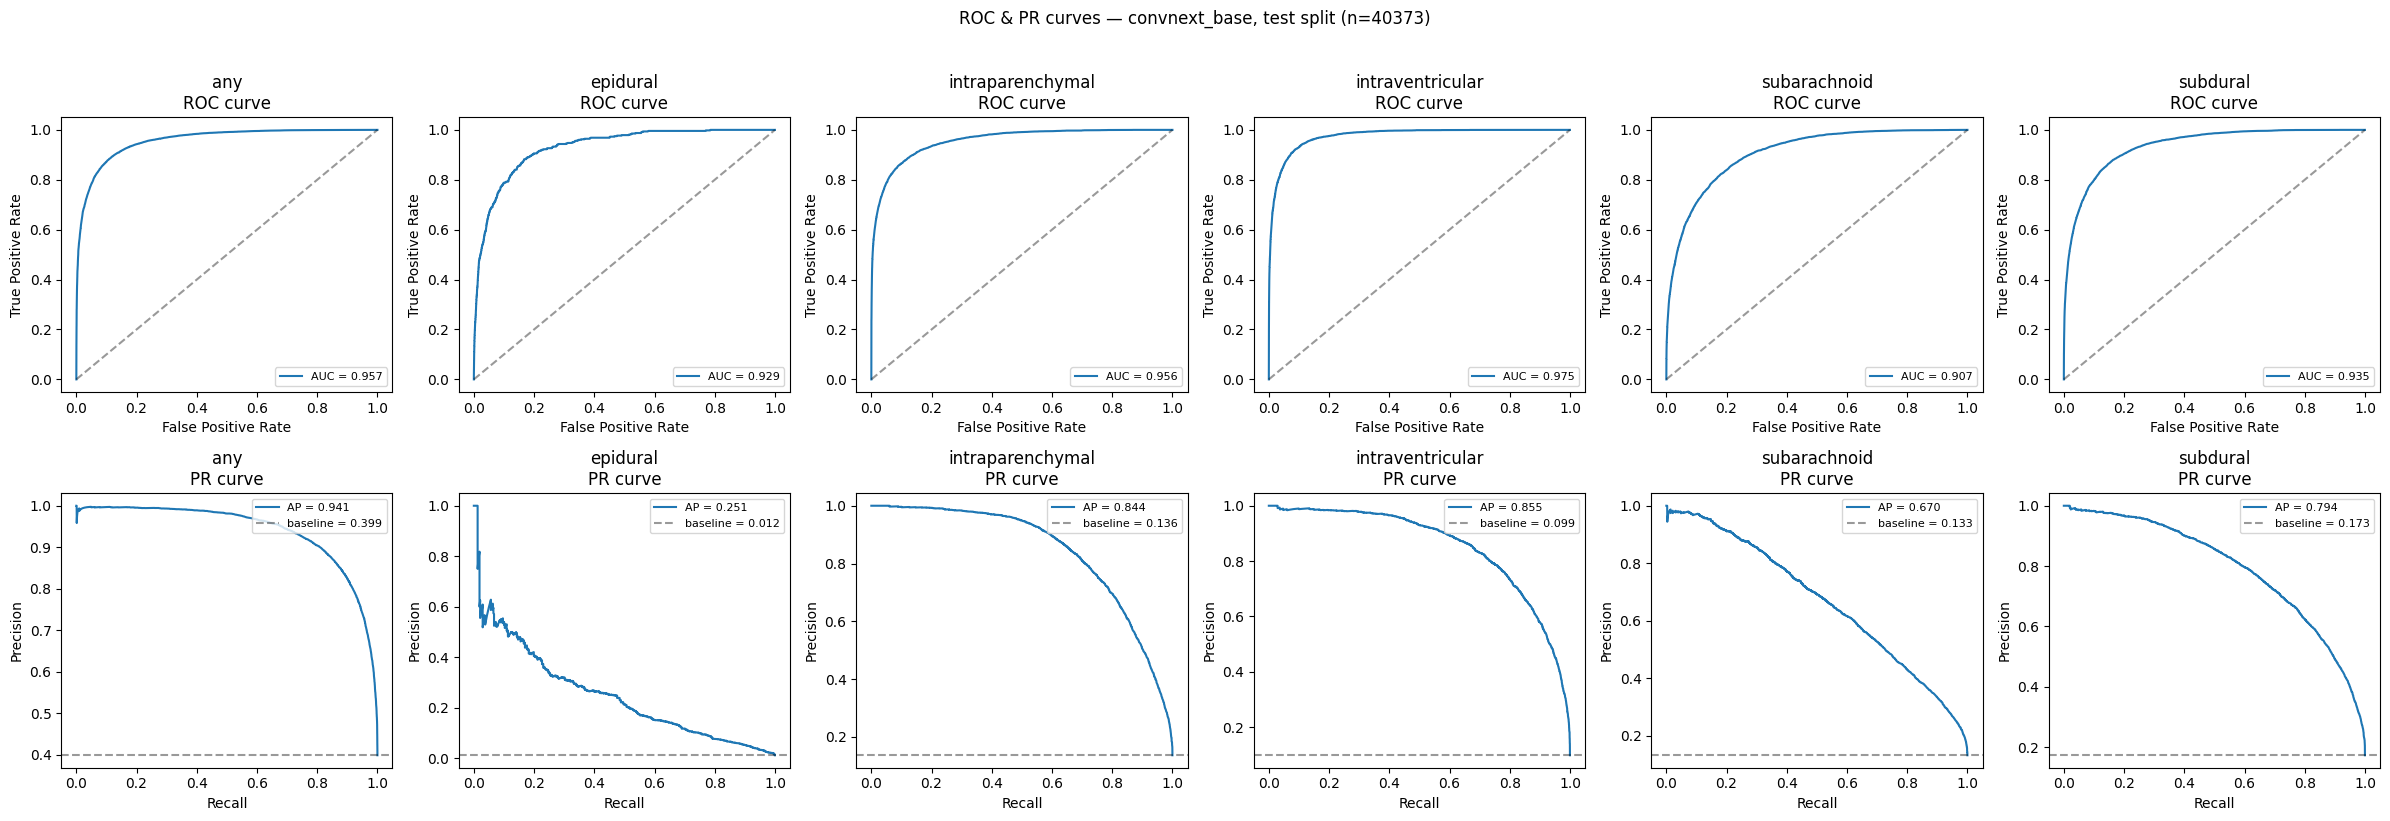

Saved ROC/PR curve grid to /kaggle/working/convnext_base_roc_pr_curves.png


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

n_classes = len(LABEL_COLS)
fig, axes = plt.subplots(2, n_classes, figsize=(4 * n_classes, 8))

for i, name in enumerate(LABEL_COLS):
    y_true = test_labels[:, i]
    y_prob = test_probs[:, i]

    if len(np.unique(y_true)) < 2:
        axes[0, i].set_visible(False)
        axes[1, i].set_visible(False)
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax_roc = axes[0, i]
    ax_roc.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.3f}")
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax_roc.set_title(f"{name}\nROC curve")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(fontsize=8, loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = average_precision_score(y_true, y_prob)
    base_rate = y_true.mean()
    ax_pr = axes[1, i]
    ax_pr.plot(recall, precision, label=f"AP = {pr_auc_val:.3f}")
    ax_pr.axhline(base_rate, color="k", linestyle="--", alpha=0.4,
                  label=f"baseline = {base_rate:.3f}")
    ax_pr.set_title(f"{name}\nPR curve")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=8, loc="upper right")

plt.suptitle(f"ROC & PR curves — {MODEL_NAME}, test split (n={len(test_labels)})", y=1.02)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{MODEL_NAME}_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved ROC/PR curve grid to /kaggle/working/{MODEL_NAME}_roc_pr_curves.png")

Running inference (logits) on val split (for fitting T)...
Running inference (logits) on test split (for reporting)...

Fitted temperature: T = 1.0932  (softens the model's confidence)

CALIBRATION METRICS (test split, n=40373) — convnext_base, T=1.0932
                  roc_auc  pr_auc  ece_before  ece_after  mce_before  mce_after  brier_before  brier_after  nll_before  nll_after
class                                                                                                                            
any                0.9566  0.9405      0.0340     0.0297      0.1635     0.1308        0.0823       0.0818      0.2705     0.2669
epidural           0.9291  0.2513      0.0017     0.0043      0.5179     0.4998        0.0100       0.0101      0.0425     0.0431
intraparenchymal   0.9556  0.8436      0.0067     0.0063      0.0791     0.0610        0.0470       0.0470      0.1632     0.1630
intraventricular   0.9748  0.8546      0.0095     0.0089      0.1322     0.1300        0.0330   

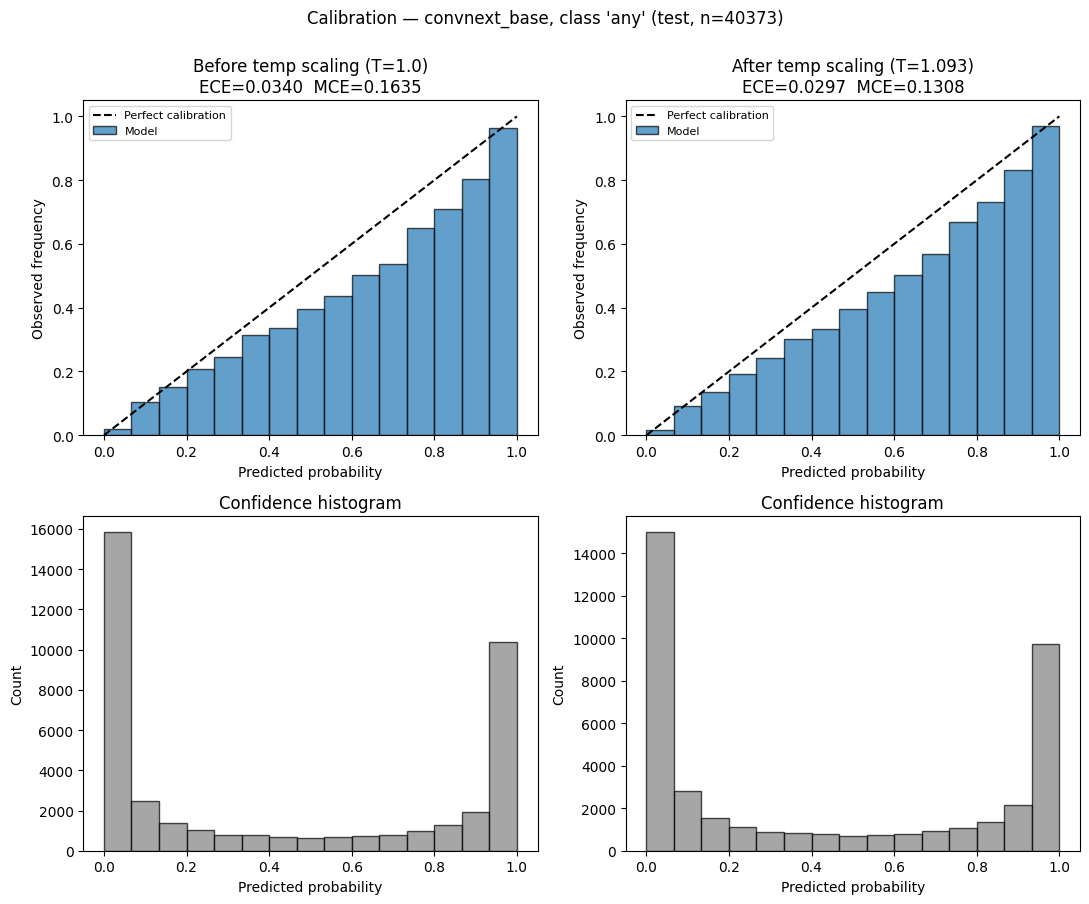


Saved calibration table to /kaggle/working/convnext_base_calibration_metrics.csv
Saved fitted T to /kaggle/working/convnext_base_temperature.txt
Saved reliability diagram to /kaggle/working/convnext_base_calibration_reliability.png


In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

N_BINS = 15


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        return logits / torch.exp(self.log_T)


@torch.no_grad()
def get_logits(loader):
    all_logits, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(imgs)
        all_logits.append(outputs.float().cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


print("Running inference (logits) on val split (for fitting T)...")
val_logits, val_labels_t = get_logits(val_loader)
print("Running inference (logits) on test split (for reporting)...")
test_logits, test_labels_t = get_logits(test_loader)

scaler = TemperatureScaler()
optimizer = torch.optim.LBFGS([scaler.log_T], lr=0.05, max_iter=100)
bce = nn.BCEWithLogitsLoss()

def closure():
    optimizer.zero_grad()
    loss = bce(scaler(val_logits), val_labels_t)
    loss.backward()
    return loss

optimizer.step(closure)
T = torch.exp(scaler.log_T).item()
print(f"\nFitted temperature: T = {T:.4f}  "
      f"({'softens' if T > 1 else 'sharpens'} the model's confidence)")


def expected_and_max_calibration_error(y_true, y_prob, n_bins=15):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    bin_accs, bin_confs, bin_counts = [], [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob > lo) & (y_prob <= hi)
        count = mask.sum()
        if count == 0:
            bin_accs.append(np.nan)
            bin_confs.append((lo + hi) / 2)
            bin_counts.append(0)
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        gap = abs(acc - conf)
        ece += (count / len(y_prob)) * gap
        mce = max(mce, gap)
        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(count)
    return ece, mce, bin_edges, bin_accs, bin_confs, bin_counts


def nll(y_true, y_prob):
    eps = 1e-12
    p = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


test_labels_np = test_labels_t.numpy()
probs_before = torch.sigmoid(test_logits).numpy()
probs_after = torch.sigmoid(test_logits / T).numpy()

rows = []
for i, name in enumerate(LABEL_COLS):
    y_true = test_labels_np[:, i]
    if len(np.unique(y_true)) < 2:
        continue

    p_before, p_after = probs_before[:, i], probs_after[:, i]
    ece_b, mce_b, *_ = expected_and_max_calibration_error(y_true, p_before, N_BINS)
    ece_a, mce_a, *_ = expected_and_max_calibration_error(y_true, p_after, N_BINS)

    rows.append({
        "class": name,
        "roc_auc": roc_auc_score(y_true, p_before),
        "pr_auc": average_precision_score(y_true, p_before),
        "ece_before": ece_b, "ece_after": ece_a,
        "mce_before": mce_b, "mce_after": mce_a,
        "brier_before": brier_score_loss(y_true, p_before),
        "brier_after": brier_score_loss(y_true, p_after),
        "nll_before": nll(y_true, p_before),
        "nll_after": nll(y_true, p_after),
    })

calib_results_df = pd.DataFrame(rows).set_index("class")
print("\n" + "=" * 100)
print(f"CALIBRATION METRICS (test split, n={len(test_labels_np)}) — {MODEL_NAME}, T={T:.4f}")
print("=" * 100)
print(calib_results_df.round(4).to_string())

macro_ece_before = calib_results_df["ece_before"].mean()
macro_ece_after = calib_results_df["ece_after"].mean()
macro_brier_before = calib_results_df["brier_before"].mean()
macro_brier_after = calib_results_df["brier_after"].mean()
print(f"\nMacro-avg ECE:   before={macro_ece_before:.4f} -> after={macro_ece_after:.4f}")
print(f"Macro-avg Brier: before={macro_brier_before:.4f} -> after={macro_brier_after:.4f}")

any_idx = LABEL_COLS.index("any")
y_true_any = test_labels_np[:, any_idx]
p_before_any = probs_before[:, any_idx]
p_after_any = probs_after[:, any_idx]

ece_b, mce_b, edges_b, accs_b, confs_b, counts_b = expected_and_max_calibration_error(
    y_true_any, p_before_any, N_BINS)
ece_a, mce_a, edges_a, accs_a, confs_a, counts_a = expected_and_max_calibration_error(
    y_true_any, p_after_any, N_BINS)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
bin_centers = (edges_b[:-1] + edges_b[1:]) / 2
bin_width = 1 / N_BINS

for col, (accs, counts, ece, mce, label) in enumerate([
    (accs_b, counts_b, ece_b, mce_b, "Before temp scaling (T=1.0)"),
    (accs_a, counts_a, ece_a, mce_a, f"After temp scaling (T={T:.3f})"),
]):
    valid = [not np.isnan(a) for a in accs]
    ax_rel = axes[0, col]
    ax_rel.bar(np.array(bin_centers)[valid], np.array(accs)[valid],
               width=bin_width, edgecolor="black", alpha=0.7, label="Model")
    ax_rel.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax_rel.set_xlabel("Predicted probability")
    ax_rel.set_ylabel("Observed frequency")
    ax_rel.set_title(f"{label}\nECE={ece:.4f}  MCE={mce:.4f}")
    ax_rel.legend(fontsize=8)

    ax_hist = axes[1, col]
    ax_hist.bar(bin_centers, counts, width=bin_width, edgecolor="black", alpha=0.7, color="gray")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title("Confidence histogram")

plt.suptitle(f"Calibration — {MODEL_NAME}, class 'any' (test, n={len(test_labels_np)})", y=1.00)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{MODEL_NAME}_calibration_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

out_path = f"/kaggle/working/{MODEL_NAME}_calibration_metrics.csv"
calib_results_df.to_csv(out_path)
with open(f"/kaggle/working/{MODEL_NAME}_temperature.txt", "w") as f:
    f.write(f"T={T:.6f}\n")
print(f"\nSaved calibration table to {out_path}")
print(f"Saved fitted T to /kaggle/working/{MODEL_NAME}_temperature.txt")
print(f"Saved reliability diagram to /kaggle/working/{MODEL_NAME}_calibration_reliability.png")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.9 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
[any] computing CAMs for 30 images (14355 available)...


any:   0%|          | 0/30 [00:00<?, ?it/s]

[epidural] computing CAMs for 30 images (183 available)...


epidural:   0%|          | 0/30 [00:00<?, ?it/s]

[intraparenchymal] computing CAMs for 30 images (3910 available)...


...

intraventricular:   0%|          | 0/30 [00:00<?, ?it/s]

[subarachnoid] computing CAMs for 30 images (3351 available)...


subarachnoid:   0%|          | 0/30 [00:00<?, ?it/s]

[subdural] computing CAMs for 30 images (4994 available)...


subdural:   0%|          | 0/30 [00:00<?, ?it/s]

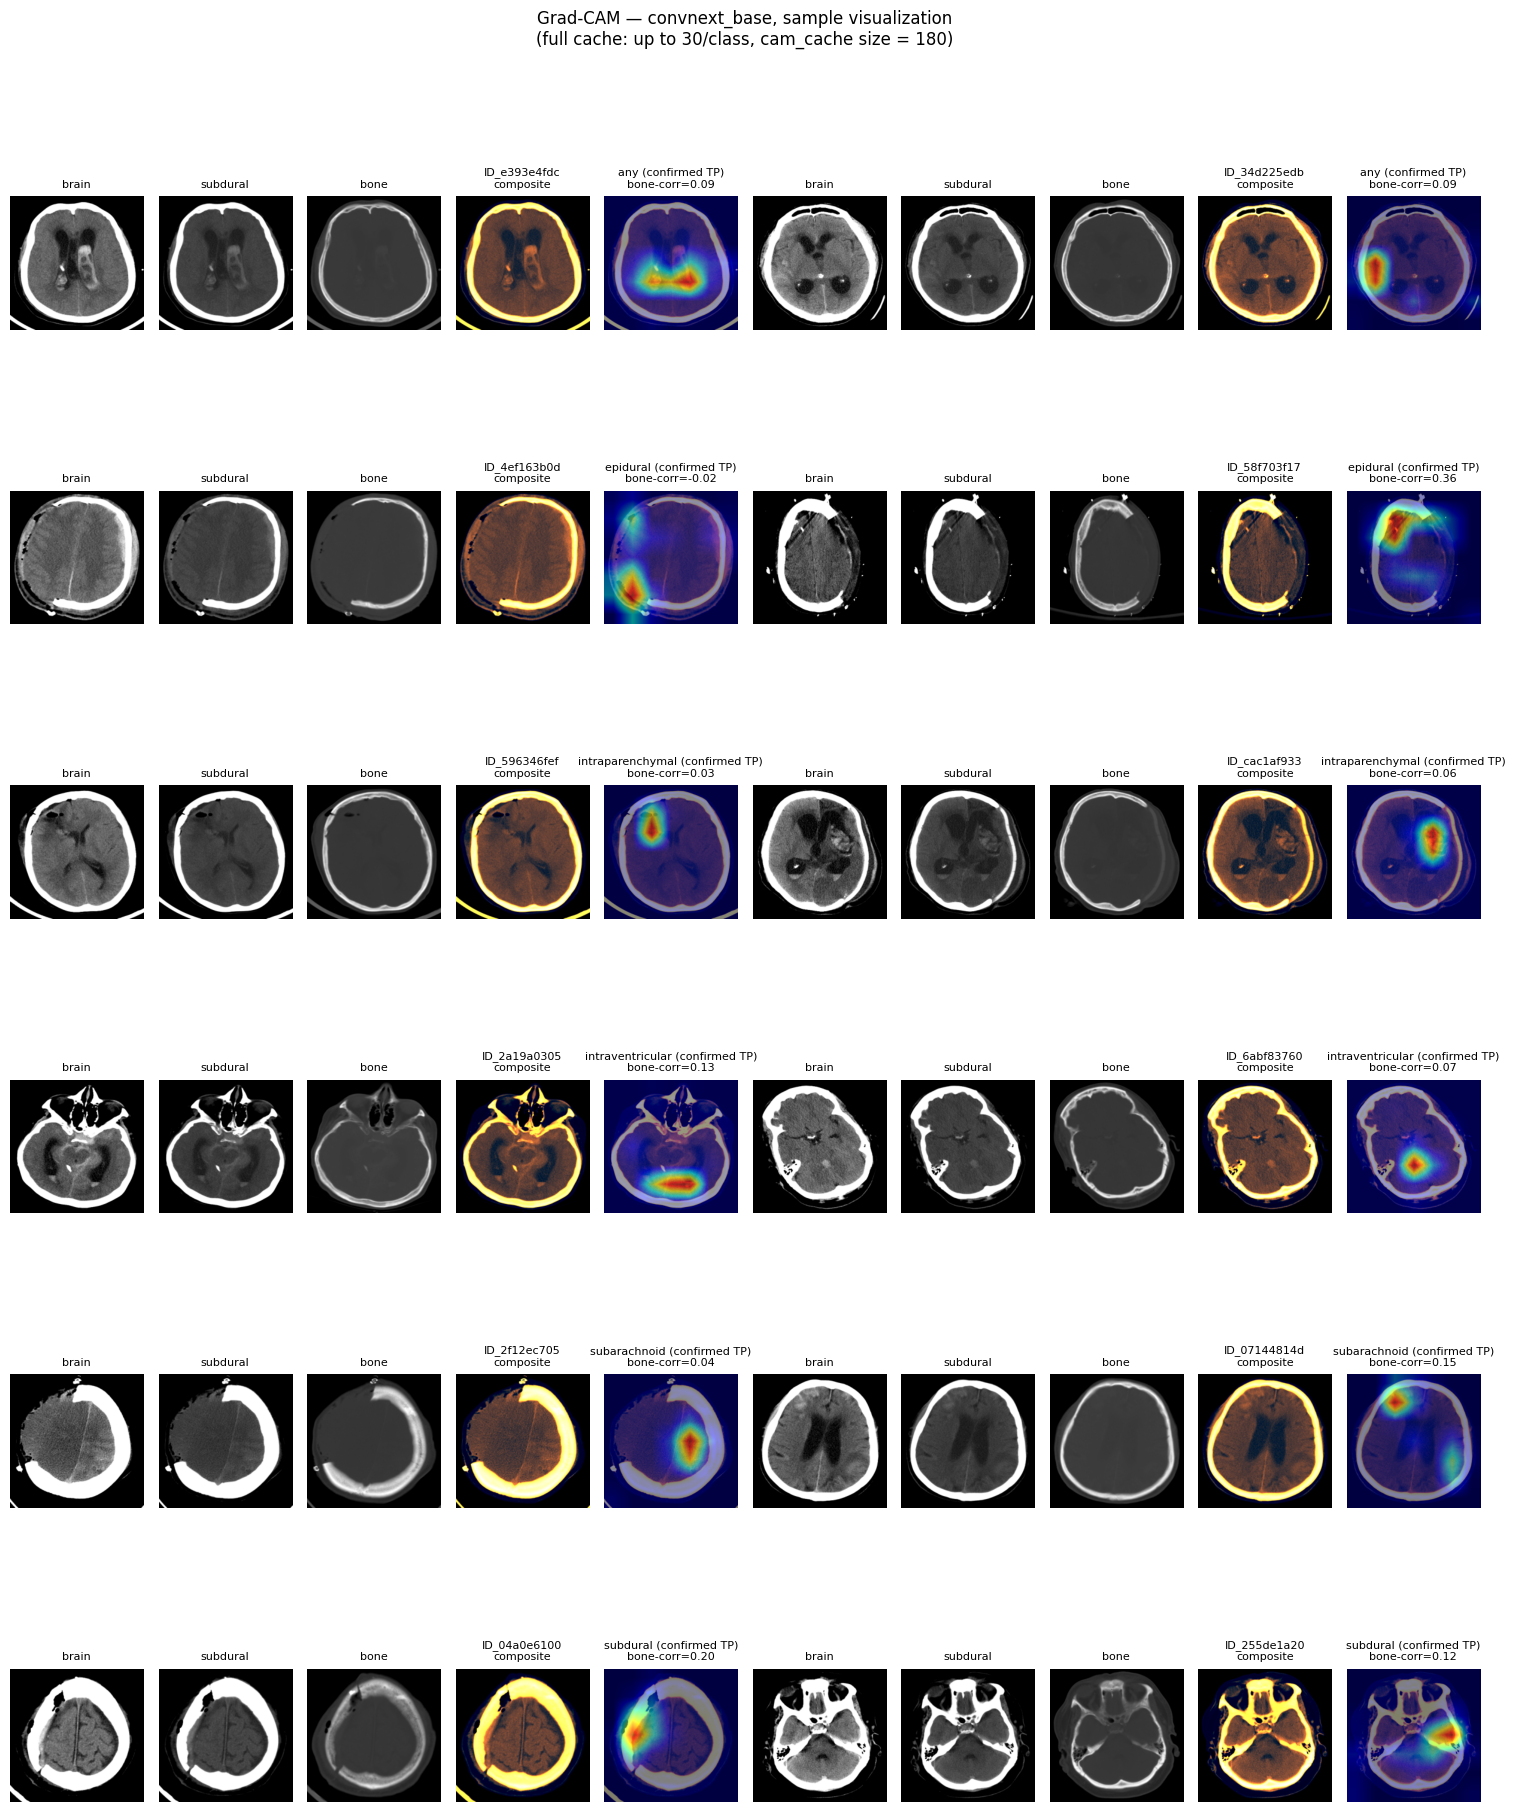


Sample sizes used per class:
           class  n_available  n_sampled
             any        14355         30
        epidural          183         30
intraparenchymal         3910         30
intraventricular         3088         30
    subarachnoid         3351         30
        subdural         4994         30

Saved cam_cache + img_cache (180 images) to /kaggle/working/cam_cache.pkl

BONE-CHANNEL SHORTCUT CHECK (full sampled set)
                   mean    std  count
class                                
any               0.077  0.081     30
epidural          0.082  0.119     30
intraparenchymal  0.064  0.047     30
intraventricular  0.082  0.058     30
subarachnoid      0.086  0.075     30
subdural          0.107  0.069     30

Saved per-example bone-correlation records to /kaggle/working/convnext_base_bone_shortcut_correlations.csv


In [8]:
!pip install grad-cam -q

import os
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------------------------------------------------------------
# GRAD-CAM — ConvNeXt-Base. Target layer: model.features[-1][-1], the
# last block of the final stage. ConvNeXt keeps standard 4D conv
# feature maps (unlike ViT), so plain GradCAM applies without a
# reshape_transform.
# ------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_CAM_SAMPLES = 30
N_VISUALIZE_PER_CLASS = 2

GRADCAM_OUT_DIR = "/kaggle/working/gradcam_examples"
CAM_CACHE_PATH = "/kaggle/working/cam_cache.pkl"
os.makedirs(GRADCAM_OUT_DIR, exist_ok=True)

CHANNEL_NAMES = ["brain", "subdural", "bone"]

target_layers = [model.features[-1][-1]]
cam = GradCAM(model=model, target_layers=target_layers)

cam_cache = {}
img_cache = {}
bone_corr_records = []


def load_image_for_cam(path):
    img = Image.open(path).convert("RGB").resize((224, 224))
    img_np = np.array(img).astype(np.float32) / 255.0
    input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    return input_tensor, img_np


def bone_shortcut_correlation(grayscale_cam, bone_channel):
    cam_flat = grayscale_cam.flatten()
    bone_flat = bone_channel.flatten()
    if cam_flat.std() < 1e-8 or bone_flat.std() < 1e-8:
        return np.nan
    return float(np.corrcoef(cam_flat, bone_flat)[0, 1])


def compute_gradcam(img_id, class_idx, class_name, id_to_path):
    path = id_to_path[img_id]
    input_tensor, img_np = load_image_for_cam(path)
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    cam_cache.setdefault(img_id, {})[class_name] = grayscale_cam
    img_cache[img_id] = img_np

    bone_channel = img_np[:, :, 2]
    corr = bone_shortcut_correlation(grayscale_cam, bone_channel)
    bone_corr_records.append({"img_id": img_id, "class": class_name, "bone_corr": corr})

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return img_np, visualization, grayscale_cam, corr


def show_and_save_gradcam_panel(img_id, class_idx, class_name, id_to_path, fig_axes, tag=""):
    img_np, visualization, grayscale_cam, corr = compute_gradcam(
        img_id, class_idx, class_name, id_to_path
    )
    ax_brain, ax_subdural, ax_bone, ax_composite, ax_cam = fig_axes

    ax_brain.imshow(img_np[:, :, 0], cmap="gray"); ax_brain.set_title("brain", fontsize=8); ax_brain.axis("off")
    ax_subdural.imshow(img_np[:, :, 1], cmap="gray"); ax_subdural.set_title("subdural", fontsize=8); ax_subdural.axis("off")
    ax_bone.imshow(img_np[:, :, 2], cmap="gray"); ax_bone.set_title("bone", fontsize=8); ax_bone.axis("off")
    ax_composite.imshow(img_np); ax_composite.set_title(f"{img_id}\ncomposite", fontsize=8); ax_composite.axis("off")
    ax_cam.imshow(visualization); ax_cam.set_title(f"{class_name}{tag}\nbone-corr={corr:.2f}", fontsize=8); ax_cam.axis("off")

    out_path = os.path.join(GRADCAM_OUT_DIR, f"{class_name}_{img_id}{tag.replace(' ', '_')}.png")
    Image.fromarray(visualization).save(out_path)


test_ids_array = test_df.index.values
class_preds = {}
for class_name in results_df.index:
    class_idx = LABEL_COLS.index(class_name)
    thresh = results_df.loc[class_name, "threshold_from_val"]
    class_preds[class_name] = (test_probs[:, class_idx] >= thresh)

classes_to_show = ["any", "epidural", "intraparenchymal",
                    "intraventricular", "subarachnoid", "subdural"]

n_cols = N_VISUALIZE_PER_CLASS * 5
fig, axes = plt.subplots(len(classes_to_show), n_cols,
                          figsize=(3 * n_cols / 2, 3.2 * len(classes_to_show)))

sample_summary = []

for row, class_name in enumerate(classes_to_show):
    class_idx = LABEL_COLS.index(class_name)
    y_true = test_labels[:, class_idx]
    y_pred = class_preds[class_name]

    true_pos_mask = (y_true == 1) & (y_pred == 1)
    true_pos_ids = test_ids_array[true_pos_mask]
    true_pos_ids = np.array([i for i in true_pos_ids if i in id_to_path])

    n_available = len(true_pos_ids)
    n_sample = min(N_CAM_SAMPLES, n_available)
    sample_summary.append({"class": class_name, "n_available": n_available, "n_sampled": n_sample})

    if n_sample == 0:
        for col in range(n_cols):
            axes[row, col].set_visible(False)
        print(f"WARNING: no confirmed true positives with resolvable paths for '{class_name}'.")
        continue

    sample_ids = np.random.choice(true_pos_ids, size=n_sample, replace=False)

    print(f"[{class_name}] computing CAMs for {n_sample} images "
          f"({n_available} available)...")
    for i, img_id in enumerate(tqdm(sample_ids, desc=class_name, leave=False)):
        if i < N_VISUALIZE_PER_CLASS:
            panel_axes = axes[row, i * 5:(i + 1) * 5]
            show_and_save_gradcam_panel(img_id, class_idx, class_name, id_to_path,
                                         panel_axes, tag=" (confirmed TP)")
        else:
            compute_gradcam(img_id, class_idx, class_name, id_to_path)

    for col in range(min(N_VISUALIZE_PER_CLASS, n_sample) * 5, n_cols):
        axes[row, col].set_visible(False)

plt.suptitle(f"Grad-CAM — {MODEL_NAME}, sample visualization\n"
             f"(full cache: up to {N_CAM_SAMPLES}/class, cam_cache size = {len(cam_cache)})",
             y=1.001)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{MODEL_NAME}_gradcam_sample_visualization.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"\nSample sizes used per class:")
print(pd.DataFrame(sample_summary).to_string(index=False))

with open(CAM_CACHE_PATH, "wb") as f:
    pickle.dump({"cam_cache": cam_cache, "img_cache": img_cache}, f)
print(f"\nSaved cam_cache + img_cache ({len(cam_cache)} images) to {CAM_CACHE_PATH}")

bone_corr_df = pd.DataFrame(bone_corr_records)
print("\n" + "=" * 70)
print("BONE-CHANNEL SHORTCUT CHECK (full sampled set)")
print("=" * 70)
print(bone_corr_df.groupby("class")["bone_corr"].agg(["mean", "std", "count"]).round(3))

bone_corr_out = f"/kaggle/working/{MODEL_NAME}_bone_shortcut_correlations.csv"
bone_corr_df.to_csv(bone_corr_out, index=False)
print(f"\nSaved per-example bone-correlation records to {bone_corr_out}")

In [10]:
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ------------------------------------------------------------------
# AOPC + MAX-SENSITIVITY — ConvNeXt-Base, Grad-CAM explainability validation
# ------------------------------------------------------------------
# Per-channel mean-fill baseline, 16x16 patch grid (14px patches).
# ConvNeXt-Base has the same 32x total downsampling as ResNet50, so
# the last stage's feature map is also 7x7 at 224x224 input — this
# patch resolution is consistent across all three models.

N_SAMPLES_PER_CLASS = 50
N_AOPC_STEPS = 10
GRID_SIZE = 16
N_SENSITIVITY_REPEATS = 10
NOISE_STD_FRACTION = 0.05

np.random.seed(RANDOM_SEED)
patch_size = 224 // GRID_SIZE


def normalize_np_to_tensor(img_np):
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    normed = (img_np - mean) / std
    tensor = torch.from_numpy(normed.transpose(2, 0, 1)).unsqueeze(0).float().to(DEVICE)
    return tensor


@torch.no_grad()
def get_class_prob(img_np, class_idx):
    input_tensor = normalize_np_to_tensor(img_np)
    with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
        outputs = model(input_tensor)
    return torch.sigmoid(outputs.float())[0, class_idx].item()


def cam_to_patch_ranking(grayscale_cam):
    patch_scores = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            patch = grayscale_cam[i * patch_size:(i + 1) * patch_size,
                                   j * patch_size:(j + 1) * patch_size]
            patch_scores[i, j] = patch.mean()
    flat_order = np.argsort(-patch_scores.flatten())
    return flat_order


def perturb_patches(img_np, patch_indices_to_remove):
    perturbed = img_np.copy()
    channel_means = img_np.reshape(-1, 3).mean(axis=0)
    for flat_idx in patch_indices_to_remove:
        i, j = divmod(flat_idx, GRID_SIZE)
        perturbed[i * patch_size:(i + 1) * patch_size,
                  j * patch_size:(j + 1) * patch_size, :] = channel_means
    return perturbed


def compute_aopc(img_np, grayscale_cam, class_idx):
    ranking = cam_to_patch_ranking(grayscale_cam)
    total_patches = GRID_SIZE * GRID_SIZE
    original_prob = get_class_prob(img_np, class_idx)

    drops = []
    for step in range(1, N_AOPC_STEPS + 1):
        n_remove = int(total_patches * step / N_AOPC_STEPS)
        perturbed_img = perturb_patches(img_np, ranking[:n_remove])
        perturbed_prob = get_class_prob(perturbed_img, class_idx)
        drops.append(original_prob - perturbed_prob)

    return float(np.mean(drops))


def compute_max_sensitivity(img_id, class_idx, class_name, id_to_path):
    path = id_to_path[img_id]
    orig_tensor, orig_img_np = load_image_for_cam(path)
    targets = [ClassifierOutputTarget(class_idx)]

    orig_cam = cam(input_tensor=orig_tensor, targets=targets)[0, :]
    noise_std = NOISE_STD_FRACTION * orig_img_np.std()

    max_diff = 0.0
    for _ in range(N_SENSITIVITY_REPEATS):
        noise = np.random.normal(0, noise_std, orig_img_np.shape).astype(np.float32)
        noisy_img = np.clip(orig_img_np + noise, 0, 1)
        noisy_tensor = normalize_np_to_tensor(noisy_img)
        noisy_cam = cam(input_tensor=noisy_tensor, targets=targets)[0, :]
        diff = np.linalg.norm(orig_cam - noisy_cam)
        max_diff = max(max_diff, diff)

    return float(max_diff)


test_ids_array = test_df.index.values
records = []

for class_name in results_df.index:
    class_idx = LABEL_COLS.index(class_name)
    y_true = test_labels[:, class_idx]
    y_pred = class_preds[class_name]

    true_pos_mask = (y_true == 1) & (y_pred == 1)
    true_pos_ids = test_ids_array[true_pos_mask]
    true_pos_ids = np.array([i for i in true_pos_ids if i in id_to_path])

    n_sample = min(N_SAMPLES_PER_CLASS, len(true_pos_ids))
    if n_sample == 0:
        print(f"Skipping '{class_name}' — no confirmed true positives with resolvable paths.")
        continue

    sample_ids = np.random.choice(true_pos_ids, size=n_sample, replace=False)
    print(f"\n{class_name}: running AOPC + Max-Sensitivity on {n_sample} confirmed TPs "
          f"(available: {len(true_pos_ids)})")

    for img_id in tqdm(sample_ids, desc=class_name):
        path = id_to_path[img_id]
        _, img_np = load_image_for_cam(path)

        if img_id in cam_cache and class_name in cam_cache[img_id]:
            grayscale_cam = cam_cache[img_id][class_name]
        else:
            input_tensor, _ = load_image_for_cam(path)
            targets = [ClassifierOutputTarget(class_idx)]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
            cam_cache.setdefault(img_id, {})[class_name] = grayscale_cam

        aopc = compute_aopc(img_np, grayscale_cam, class_idx)
        max_sens = compute_max_sensitivity(img_id, class_idx, class_name, id_to_path)

        records.append({
            "class": class_name, "img_id": img_id,
            "aopc": aopc, "max_sensitivity": max_sens,
        })

explain_df = pd.DataFrame(records)
print("\n" + "=" * 90)
print(f"AOPC + MAX-SENSITIVITY SUMMARY — {MODEL_NAME}")
print("=" * 90)
print(explain_df.groupby("class")[["aopc", "max_sensitivity"]].agg(["mean", "std", "count"]).round(4))

out_path = f"/kaggle/working/{MODEL_NAME}_aopc_max_sensitivity.csv"
explain_df.to_csv(out_path, index=False)
print(f"\nSaved per-example AOPC/Max-Sensitivity records to {out_path}")


any: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 14355)


any:   0%|          | 0/50 [00:00<?, ?it/s]


epidural: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 183)


epidural:   0%|          | 0/50 [00:00<?, ?it/s]


intraparenchymal: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 3910)


...


subarachnoid: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 3351)


subarachnoid:   0%|          | 0/50 [00:00<?, ?it/s]


subdural: running AOPC + Max-Sensitivity on 50 confirmed TPs (available: 4994)


subdural:   0%|          | 0/50 [00:00<?, ?it/s]


AOPC + MAX-SENSITIVITY SUMMARY — convnext_base
                    aopc               max_sensitivity               
                    mean     std count            mean      std count
class                                                                
any               0.4597  0.1872    50         20.1052  13.9192    50
epidural          0.3380  0.1381    50         18.2150   6.9497    50
intraparenchymal  0.7725  0.1988    50          7.3721   6.2315    50
intraventricular  0.7522  0.1515    50         13.4200   9.3295    50
subarachnoid      0.5592  0.2029    50         20.7250   9.5121    50
subdural          0.5255  0.1661    50         17.6109   8.8528    50

Saved per-example AOPC/Max-Sensitivity records to /kaggle/working/convnext_base_aopc_max_sensitivity.csv


In [11]:
import os
for f in sorted(os.listdir("/kaggle/working")):
    print(f)

.ipynb_checkpoints
.virtual_documents
cam_cache.pkl
checkpoints
convnext_base_aopc_max_sensitivity.csv
convnext_base_bone_shortcut_correlations.csv
convnext_base_calibration_metrics.csv
convnext_base_calibration_reliability.png
convnext_base_eval_metrics.csv
convnext_base_gradcam_sample_visualization.png
convnext_base_roc_pr_curves.png
convnext_base_temperature.txt
gradcam_examples
test_ids.csv


In [12]:
import shutil
import os

# Copy just what you want into a clean folder first, then zip that
os.makedirs("/kaggle/working/export", exist_ok=True)
files_to_zip = [
    "cam_cache.pkl",
    "convnext_base_aopc_max_sensitivity.csv",
    "convnext_base_bone_shortcut_correlations.csv",
    "convnext_base_calibration_metrics.csv",
    "convnext_base_calibration_reliability.png",
    "convnext_base_eval_metrics.csv",
    "convnext_base_gradcam_sample_visualization.png",
    "convnext_base_roc_pr_curves.png",
    "convnext_base_temperature.txt",
    "test_ids.csv",
]
for f in files_to_zip:
    shutil.copy(f"/kaggle/working/{f}", f"/kaggle/working/export/{f}")

shutil.copytree("/kaggle/working/gradcam_examples", "/kaggle/working/export/gradcam_examples")

shutil.make_archive("/kaggle/working/convnext_base_all_outputs", "zip", "/kaggle/working/export")
print("Zipped to /kaggle/working/convnext_base_all_outputs.zip")

Zipped to /kaggle/working/convnext_base_all_outputs.zip
